# Estudo de Público-Alvo (Behavior / Credit Risk Profiling)

Objetivo:
1. Caracterizar a população elegível do modelo (grão cpf+safra+prod).
2. Identificar onde o risco se concentra (por produto, safra e segmentos comportamentais).
3. Medir cobertura de informação (recarga, pagamento, atraso, bureau/cadastro).
4. Produzir artefatos para slides: tabelas e gráficos com mensagens acionáveis.

Princípios de credit scoring:
- AS-OF: variáveis devem ser observáveis antes da decisão (validado na auditoria de vazamento).
- Estabilidade: comportamento e risco devem ser avaliados por safra.
- Interpretabilidade: priorizar segmentações e curvas monotônicas.


## Imports

In [13]:
import os
import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from urllib.parse import urlparse
from pathlib import Path

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 200)

ASSETS_DIR = Path("../../docs/slides_assets/estudo_publico")
ASSETS_DIR.mkdir(parents=True, exist_ok=True)
ABT_PATH = "s3://lake/gold/abt_base_prod/**/*.parquet"


## Helpers

In [3]:
def get_duckdb_connection(memory_limit: str = "4GB", threads: int = 4) -> duckdb.DuckDBPyConnection:
    endpoint = os.getenv("S3_ENDPOINT")
    if not endpoint:
        raise RuntimeError("S3_ENDPOINT nao definido no ambiente (.env).")

    parsed = urlparse(endpoint)
    if not parsed.netloc:
        raise RuntimeError(f"S3_ENDPOINT invalido: {endpoint}")

    duckdb_endpoint = parsed.netloc
    con = duckdb.connect()

    con.execute(f"""
        INSTALL httpfs;
        LOAD httpfs;

        SET memory_limit='{memory_limit}';
        SET threads={threads};

        SET s3_endpoint='{duckdb_endpoint}';
        SET s3_access_key_id='{os.getenv("AWS_ACCESS_KEY_ID")}';
        SET s3_secret_access_key='{os.getenv("AWS_SECRET_ACCESS_KEY")}';
        SET s3_region='{os.getenv("AWS_DEFAULT_REGION", "us-east-1")}';
        SET s3_use_ssl=false;
        SET s3_url_style='path';
    """)
    return con

con = get_duckdb_connection(memory_limit="4GB", threads=4)


## Main Code

In [52]:
# colunas mínimas para o estudo
COLS = [
    "num_cpf","safra","prod","fpd","ano_mes",
    "bur_score_01","bur_score_02",
    "cad_datadenascimento","cad_statusrf",
    "rec_qtd_l30d","rec_qtd_l60d","rec_qtd_l90d","rec_qtd_geral","rec_dias_desde_ultima",
    "rec_vlr_total_l30d","rec_vlr_total_l60d","rec_vlr_total_l90d","rec_vlr_total_geral",
    "rec_vlr_avg_l30d","rec_vlr_avg_l60d","rec_vlr_avg_l90d","rec_vlr_avg_geral",
    "rec_flag_sem_recarga_l30d","rec_flag_sem_recarga_l60d","rec_flag_sem_recarga_l90d",
    "pag_qtd_faturas_l30d","pag_qtd_faturas_l60d","pag_qtd_faturas_l90d","pag_qtd_faturas_geral",
    "pag_flag_sem_pagamento_l30d","pag_flag_sem_pagamento_l60d","pag_flag_sem_pagamento_l90d",
    "pag_dias_desde_ultimo_pagamento",
    "atr_qtd_faturas_atrasadas_l30d","atr_qtd_faturas_atrasadas_l60d","atr_qtd_faturas_atrasadas_l90d","atr_qtd_faturas_atrasadas_geral",
    "atr_flag_recorrente_l30d","atr_flag_recorrente_l60d","atr_flag_recorrente_l90d",
    "atr_flag_atraso_l30d","atr_flag_atraso_l60d","atr_flag_atraso_l90d",
    "atr_dias_desde_ultimo_atraso"
]

select_clause = ", ".join(COLS)

In [14]:
df = con.execute(f"""
    SELECT {select_clause}
    FROM read_parquet('{ABT_PATH}')
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [15]:
df[['safra', 'fpd', 'prod']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1321168 entries, 0 to 1321167
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   safra   1321168 non-null  datetime64[us]
 1   fpd     1321168 non-null  bool          
 2   prod    1321168 non-null  object        
dtypes: bool(1), datetime64[us](1), object(1)
memory usage: 21.4+ MB


In [16]:
df["fpd"] = df["fpd"].astype(int)
df["prod"] = df["prod"].astype("category")

In [17]:
df[['safra', 'fpd', 'prod']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1321168 entries, 0 to 1321167
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   safra   1321168 non-null  datetime64[us]
 1   fpd     1321168 non-null  int64         
 2   prod    1321168 non-null  category      
dtypes: category(1), datetime64[us](1), int64(1)
memory usage: 21.4 MB


In [18]:
print("Dataset:", df.shape)
print("Safras:", df["safra"].nunique(), sorted(df["safra"].dt.date.unique()))
print("Produtos:", df["prod"].nunique(), df["prod"].cat.categories.tolist())
print("FPD médio:", round(df["fpd"].mean()*100, 2), "%")

Dataset: (1321168, 43)
Safras: 6 [datetime.date(2024, 10, 1), datetime.date(2024, 11, 1), datetime.date(2024, 12, 1), datetime.date(2025, 1, 1), datetime.date(2025, 2, 1), datetime.date(2025, 3, 1)]
Produtos: 3 ['CMV', 'DTH', 'NET']
FPD médio: 23.79 %


## Estatísticas básicas
Pode servir como: População e estabilidade do target (slides 1–2)

In [21]:
pop_summary = pd.DataFrame({
    "n_linhas": [len(df)],
    "cpfs_unicos": [df["num_cpf"].nunique()],
    "safras": [df["safra"].nunique()],
    "produtos": [df["prod"].nunique()],
    "fpd_rate": [df["fpd"].mean()]
})
pop_summary


,n_linhas,cpfs_unicos,safras,produtos,fpd_rate
0,1321168,1272095,6,3,0.237918


In [22]:
pop_summary.to_csv(ASSETS_DIR / "pop_summary.csv", index=False)

## FPD por safra (estabilidade temporal)

In [23]:
fpd_by_safra = (
    df.groupby("safra")
      .agg(volume=("fpd","count"), fpd_rate=("fpd","mean"))
      .reset_index()
      .sort_values("safra")
)
fpd_by_safra

,safra,volume,fpd_rate
0,2024-10-01,207953,0.228379
1,2024-11-01,231824,0.250457
2,2024-12-01,232984,0.241274
3,2025-01-01,226446,0.238331
4,2025-02-01,208731,0.226981
5,2025-03-01,213230,0.240191


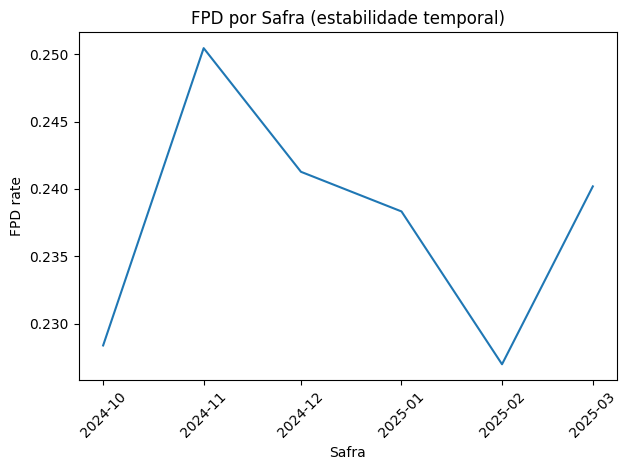

In [24]:
plt.figure()
plt.plot(fpd_by_safra["safra"], fpd_by_safra["fpd_rate"])
plt.title("FPD por Safra (estabilidade temporal)")
plt.xlabel("Safra")
plt.ylabel("FPD rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "fpd_by_safra.png", dpi=200)
plt.show()

In [25]:
fpd_by_safra.to_csv(ASSETS_DIR / "fpd_by_safra.csv", index=False)

## FPD por produto (risco estrutural)

In [26]:
fpd_by_prod = (
    df.groupby("prod")
      .agg(volume=("fpd","count"), fpd_rate=("fpd","mean"))
      .assign(share=lambda x: x["volume"]/x["volume"].sum())
      .reset_index()
      .sort_values("volume", ascending=False)
)

fpd_by_prod

C:\Users\lance\AppData\Local\Temp\ipykernel_61552\3791286973.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("prod")


,prod,volume,fpd_rate,share
0,CMV,1308974,0.237251,0.990770
2,NET,10043,0.261476,0.007602
1,DTH,2151,0.534170,0.001628


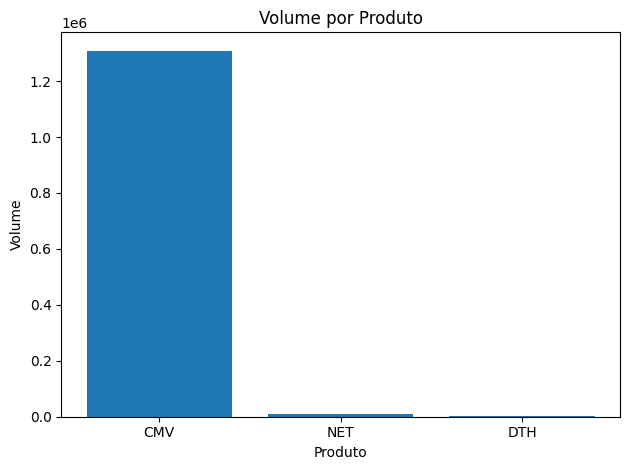

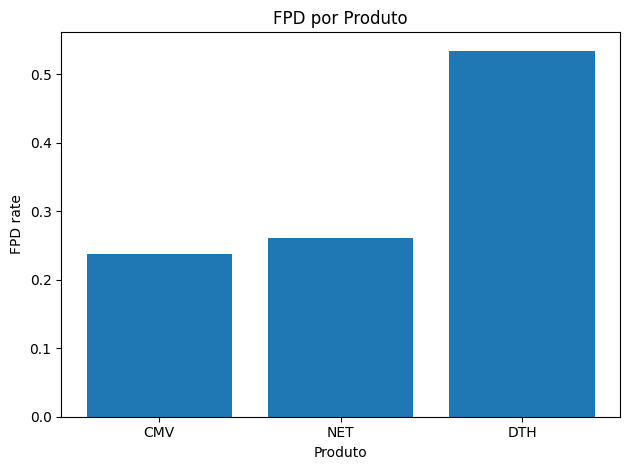

In [27]:
plt.figure()
plt.bar(fpd_by_prod["prod"].astype(str), fpd_by_prod["volume"])
plt.title("Volume por Produto")
plt.xlabel("Produto")
plt.ylabel("Volume")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "volume_by_prod.png", dpi=200)
plt.show()

plt.figure()
plt.bar(fpd_by_prod["prod"].astype(str), fpd_by_prod["fpd_rate"])
plt.title("FPD por Produto")
plt.xlabel("Produto")
plt.ylabel("FPD rate")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "fpd_by_prod.png", dpi=200)
plt.show()

In [28]:
fpd_by_prod.to_csv(ASSETS_DIR / "fpd_by_prod.csv", index=False)

## Cobertura de domínios (rec/pag/atr/bureau/cadastro)
Definição: cobertura = % registros com dado observável (não nulo) no domínio.

In [29]:
coverage = pd.DataFrame([
    {"dominio": "Bureau (bur_score_02)", "coverage": df["bur_score_02"].notna().mean()},
    {"dominio": "Cadastro (nascimento)", "coverage": df["cad_datadenascimento"].notna().mean()},
    {"dominio": "Recarga (rec_qtd_l90d)", "coverage": df["rec_qtd_l90d"].notna().mean()},
    {"dominio": "Pagamento (pag_qtd_faturas_l90d)", "coverage": df["pag_qtd_faturas_l90d"].notna().mean()},
    {"dominio": "Atraso (atr_qtd_faturas_atrasadas_l90d)", "coverage": df["atr_qtd_faturas_atrasadas_l90d"].notna().mean()},
]).sort_values("coverage", ascending=False)

coverage


,dominio,coverage
2,Recarga (rec_qtd_l90d),1.000000
4,Atraso (atr_qtd_faturas_atrasadas_l90d),1.000000
3,Pagamento (pag_qtd_faturas_l90d),1.000000
1,Cadastro (nascimento),0.998537
0,Bureau (bur_score_02),0.990282


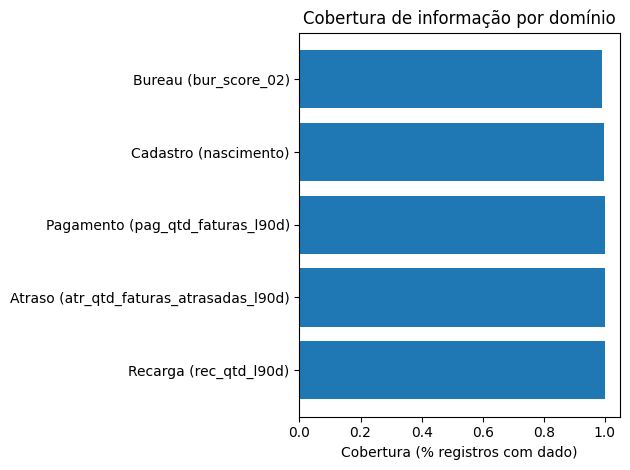

In [30]:
plt.figure()
plt.barh(coverage["dominio"], coverage["coverage"])
plt.title("Cobertura de informação por domínio")
plt.xlabel("Cobertura (% registros com dado)")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "coverage_by_domain.png", dpi=200)
plt.show()

In [31]:
coverage.to_csv(ASSETS_DIR / "coverage_by_domain.csv", index=False)

## Features derivadas para perfil (idade, bins, flags)

### Criar idade e faixas

In [34]:
df["idade"] = (
    (df["safra"] - df["cad_datadenascimento"]).dt.days / 365.25
)

In [35]:
df["idade"] = np.floor(df["idade"])
df["idade"] = df["idade"].where(df["idade"].between(0, 110), np.nan)

In [38]:
bins_idade = [0, 17, 24, 34, 44, 54, 64, 110]
labels_idade = ["<=17","18-24","25-34","35-44","45-54","55-64","65+"]

In [39]:
df["faixa_idade"] = pd.cut(df["idade"], bins=bins_idade, labels=labels_idade, right=True, include_lowest=True)

In [40]:
idade_risco = (
    df.groupby("faixa_idade")
      .agg(volume=("fpd","count"), fpd_rate=("fpd","mean"))
      .reset_index()
      .sort_values("faixa_idade")
)
idade_risco

C:\Users\lance\AppData\Local\Temp\ipykernel_61552\1343421774.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("faixa_idade")


,faixa_idade,volume,fpd_rate
0,<=17,303,0.214521
1,18-24,132889,0.278563
2,25-34,298729,0.251077
3,35-44,349639,0.236458
4,45-54,269243,0.226546
5,55-64,160952,0.213815
6,65+,107476,0.216839


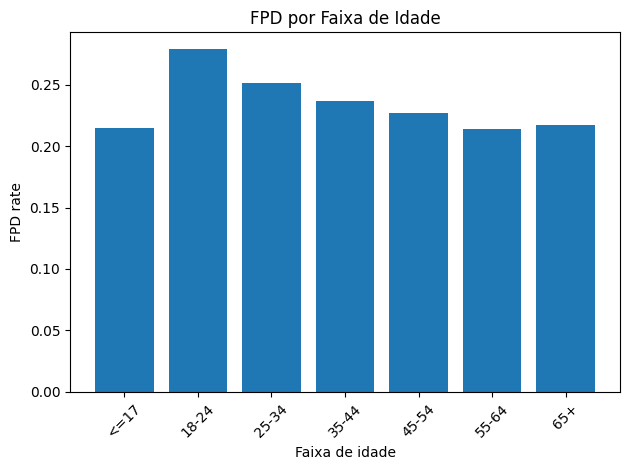

In [41]:
plt.figure()
plt.bar(idade_risco["faixa_idade"].astype(str), idade_risco["fpd_rate"])
plt.title("FPD por Faixa de Idade")
plt.xlabel("Faixa de idade")
plt.ylabel("FPD rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(ASSETS_DIR / "fpd_by_faixa_idade.png", dpi=200)
plt.show()

In [42]:
idade_risco.to_csv(ASSETS_DIR / "fpd_by_faixa_idade.csv", index=False)

## Segmentações comportamentais interpretáveis

### Segmentos principais (regras simples)

In [43]:
df["seg_sem_recarga_90d"] = (df["rec_flag_sem_recarga_l90d"] == 1).astype(int)
df["seg_sem_pagamento_90d"] = (df["pag_flag_sem_pagamento_l90d"] == 1).astype(int)
df["seg_atraso_recorrente_90d"] = (df["atr_flag_recorrente_l90d"] == 1).astype(int)
df["seg_teve_atraso_90d"] = (df["atr_flag_atraso_l90d"] == 1).astype(int)

In [44]:
segments = [
    ("Sem recarga 90d", "seg_sem_recarga_90d"),
    ("Sem pagamento 90d", "seg_sem_pagamento_90d"),
    ("Atraso recorrente 90d", "seg_atraso_recorrente_90d"),
    ("Teve atraso 90d", "seg_teve_atraso_90d"),
]

seg_rows = []
for name, col in segments:
    mask = df[col] == 1
    seg_rows.append({
        "segmento": name,
        "volume": int(mask.sum()),
        "volume_pct": float(mask.mean()),
        "fpd_rate": float(df.loc[mask, "fpd"].mean())
    })

seg_table = pd.DataFrame(seg_rows).sort_values("fpd_rate", ascending=False)
seg_table


,segmento,volume,volume_pct,fpd_rate
1,Sem pagamento 90d,1057712,0.800589,0.253872
3,Teve atraso 90d,310828,0.235268,0.245387
0,Sem recarga 90d,60596,0.045865,0.242673
2,Atraso recorrente 90d,231850,0.175489,0.205659


In [45]:
seg_table.to_csv(ASSETS_DIR / "segments_table_overall.csv", index=False)


In [46]:
seg_by_prod = []
for prod in df["prod"].cat.categories:
    d = df[df["prod"] == prod].copy()
    for name, col in segments:
        mask = d[col] == 1
        seg_by_prod.append({
            "prod": str(prod),
            "segmento": name,
            "volume": int(mask.sum()),
            "volume_pct": float(mask.mean()),
            "fpd_rate": float(d.loc[mask, "fpd"].mean()) if mask.any() else np.nan
        })

seg_by_prod = pd.DataFrame(seg_by_prod).sort_values(["prod","fpd_rate"], ascending=[True,False])
seg_by_prod.head(30)


,prod,segmento,volume,volume_pct,fpd_rate
1,CMV,Sem pagamento 90d,1050399,0.802460,0.253109
3,CMV,Teve atraso 90d,305552,0.233429,0.244531
0,CMV,Sem recarga 90d,59673,0.045588,0.242957
2,CMV,Atraso recorrente 90d,228382,0.174474,0.204915
5,DTH,Sem pagamento 90d,1312,0.609949,0.623476
7,DTH,Teve atraso 90d,970,0.450953,0.465979
6,DTH,Atraso recorrente 90d,661,0.307299,0.411498
4,DTH,Sem recarga 90d,66,0.030683,0.257576
9,NET,Sem pagamento 90d,6001,0.597531,0.306616
11,NET,Teve atraso 90d,4306,0.428756,0.256386


In [47]:
seg_by_prod.to_csv(ASSETS_DIR / "segments_table_by_prod.csv", index=False)

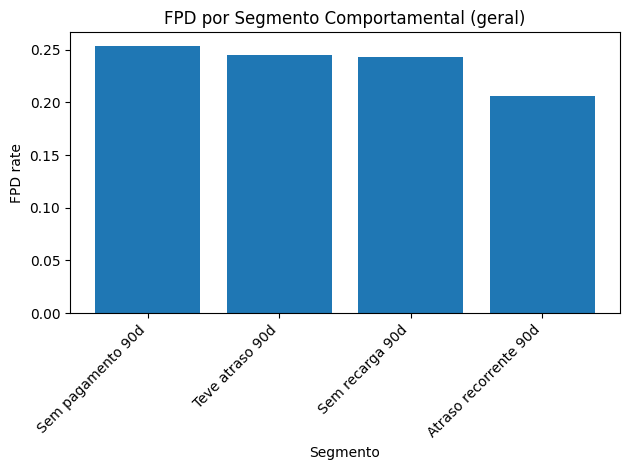

In [48]:
plt.figure()
plt.bar(seg_table["segmento"], seg_table["fpd_rate"])
plt.title("FPD por Segmento Comportamental (geral)")
plt.xlabel("Segmento")
plt.ylabel("FPD rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "fpd_by_segment_overall.png", dpi=200)
plt.show()


## Curvas monotônicas (score bureau e variáveis de comportamento)

### Decis do bur_score_02 e risco

In [49]:
dscore = df[df["bur_score_02"].notna()].copy()
dscore["decil_bur_score_02"] = pd.qcut(dscore["bur_score_02"], 10, duplicates="drop")

score_curve = (
    dscore.groupby("decil_bur_score_02")
          .agg(volume=("fpd","count"), fpd_rate=("fpd","mean"), score_min=("bur_score_02","min"), score_max=("bur_score_02","max"))
          .reset_index()
)

score_curve

C:\Users\lance\AppData\Local\Temp\ipykernel_61552\3259833411.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dscore.groupby("decil_bur_score_02")


,decil_bur_score_02,volume,fpd_rate,score_min,score_max
0,"(0.999, 508.0]",132733,0.488258,1,508
1,"(508.0, 543.0]",130294,0.378820,509,543
2,"(543.0, 571.0]",133743,0.322282,544,571
3,"(571.0, 596.0]",128128,0.275069,572,596
4,"(596.0, 622.0]",131096,0.240106,597,622
5,"(622.0, 649.0]",129005,0.203287,623,649
6,"(649.0, 680.0]",133349,0.167043,650,680
7,"(680.0, 715.0]",130376,0.133460,681,715
8,"(715.0, 760.0]",130922,0.097508,716,760
9,"(760.0, 917.0]",128683,0.058120,761,917


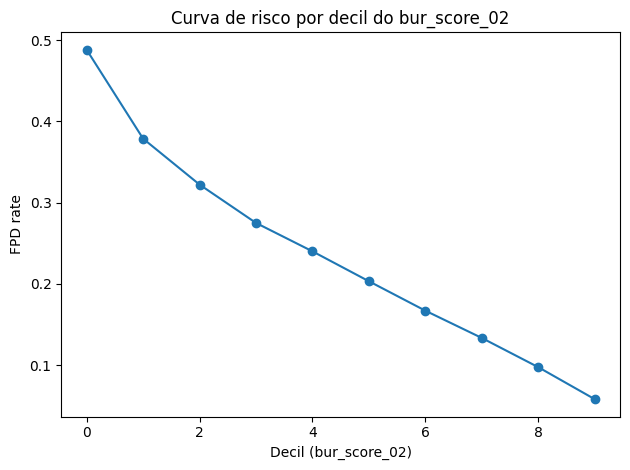

In [50]:
plt.figure()
plt.plot(range(len(score_curve)), score_curve["fpd_rate"], marker="o")
plt.title("Curva de risco por decil do bur_score_02")
plt.xlabel("Decil (bur_score_02)")
plt.ylabel("FPD rate")
plt.tight_layout()
plt.savefig(ASSETS_DIR / "risk_curve_by_bureau_decile.png", dpi=200)
plt.show()

score_curve.to_csv(ASSETS_DIR / "risk_curve_by_bureau_decile.csv", index=False)

### Curva por decil de uma variável comportamental (exemplo recência)

C:\Users\lance\AppData\Local\Temp\ipykernel_61552\2115178233.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("decil_var")


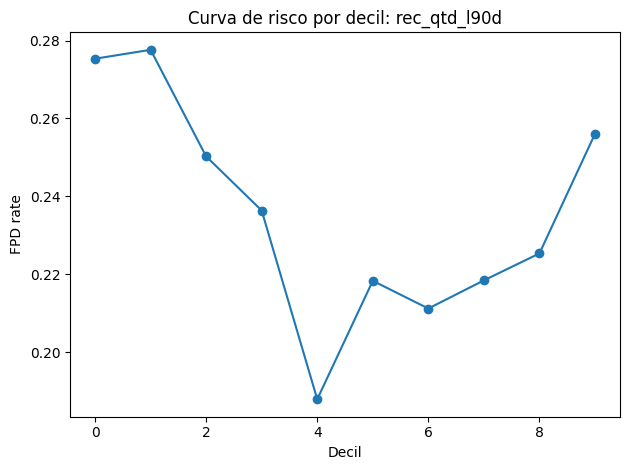

In [54]:
var = "rec_qtd_l90d"
if var in df.columns:
    tmp = df[df[var].notna()].copy()
    tmp["decil_var"] = pd.qcut(tmp[var], 10, duplicates="drop")

    curve = (
        tmp.groupby("decil_var")
           .agg(volume=("fpd","count"), fpd_rate=("fpd","mean"), vmin=(var,"min"), vmax=(var,"max"))
           .reset_index()
    )

    plt.figure()
    plt.plot(range(len(curve)), curve["fpd_rate"], marker="o")
    plt.title(f"Curva de risco por decil: {var}")
    plt.xlabel("Decil")
    plt.ylabel("FPD rate")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / f"risk_curve_{var}.png", dpi=200)
    plt.show()

    curve.to_csv(ASSETS_DIR / f"risk_curve_{var}.csv", index=False)
else:
    print(f"Variável {var} não está no dataframe mínimo. Se quiser, adicione na lista COLS.")


## Segmentos acionáveis (para política e swap-in)

In [55]:
seg_table2 = seg_table.copy()
seg_table2["prioridade"] = seg_table2["volume_pct"] * seg_table2["fpd_rate"]  # proxy simples de impacto
seg_table2 = seg_table2.sort_values("prioridade", ascending=False)
seg_table2

,segmento,volume,volume_pct,fpd_rate,prioridade
1,Sem pagamento 90d,1057712,0.800589,0.253872,0.203247
3,Teve atraso 90d,310828,0.235268,0.245387,0.057731
2,Atraso recorrente 90d,231850,0.175489,0.205659,0.036091
0,Sem recarga 90d,60596,0.045865,0.242673,0.011130


In [56]:
seg_table2.to_csv(ASSETS_DIR / "segments_priority.csv", index=False)

## Gerar resumo executivo para slides (markdown) automaticamente

In [ ]:
summary_path = Path("../../docs/business/02_estudo_publico_alvo_summary.md")
summary_path.parent.mkdir(parents=True, exist_ok=True)

def fmt_pct(x):
    return f"{x*100:.2f}%"

lines = []
lines.append("# Estudo de Público-Alvo (Resumo para Slides)\n")

lines.append("## População\n")
lines.append(f"- Volume total: {len(df):,}\n")
lines.append(f"- CPFs únicos: {df['num_cpf'].nunique():,}\n")
lines.append(f"- Safras: {df['safra'].nunique()}\n")
lines.append(f"- Produtos: {df['prod'].nunique()}\n")
lines.append(f"- FPD médio: {fmt_pct(df['fpd'].mean())}\n")

lines.append("\n## Risco por produto\n")
for _, r in fpd_by_prod.iterrows():
    lines.append(f"- {r['prod']}: share {fmt_pct(r['share'])}, FPD {fmt_pct(r['fpd_rate'])}, volume {int(r['volume']):,}\n")

lines.append("\n## Estabilidade temporal\n")
lines.append("- FPD por safra salvo em: reports/slides_assets/estudo_publico/fpd_by_safra.png\n")

lines.append("\n## Cobertura de informação\n")
for _, r in coverage.iterrows():
    lines.append(f"- {r['dominio']}: {fmt_pct(r['coverage'])}\n")

lines.append("\n## Segmentos comportamentais (geral)\n")
for _, r in seg_table.iterrows():
    lines.append(f"- {r['segmento']}: volume {fmt_pct(r['volume_pct'])}, FPD {fmt_pct(r['fpd_rate'])}\n")

lines.append("\n## Arquivos para slides\n")
lines.append("- Gráficos em: reports/slides_assets/estudo_publico/\n")
lines.append("- Tabelas em CSV no mesmo diretório\n")

summary_path.write_text("".join(lines), encoding="utf-8")
print(f"Resumo gerado em: {summary_path}")
